In [1]:
from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings

In [2]:
load_dotenv()

True

In [3]:
# Define our knowledge base

docs = [
    "UnlimitedCode is an AI education company.",
    "This is the method of cooking rice and beans",
    "UnlimitedCode helps you move to the next level in agentic coding",
    "Blood transfusion helps you get get to your system",
    "Our bootcamp teaches AI agents."
]

In [4]:
# Convert plain strings into LangChain Document objects
documents = [Document(page_content=text) for text in docs]

In [5]:
# Create embedding model
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

In [6]:
# Store documents in ChromaDB vector database

vector_store = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    persist_directory="./chroma_db"
)
# pinecone, pgvector
print(f"Vector collections created: {vector_store._collection.count()}")

Vector collections created: 5


In [7]:
# Convert vector store into a retriever object

retriever = vector_store.as_retriever(
    search_kwargs={"k":2}
)

In [8]:
query = "What does UnlimitedCode do?"
results = retriever.invoke(query)

In [9]:
print("\nRetrieved Documents:")
for i, doc in enumerate(results, start=1):
    print(f"\nResult {i}:")
    print(doc.page_content)


Retrieved Documents:

Result 1:
UnlimitedCode is an AI education company.

Result 2:
UnlimitedCode helps you move to the next level in agentic coding


#### Directly asks the vector database for the most similar documents.

In [10]:
query = "rice cooking methods?"
similar_docs = vector_store.similarity_search(query, k=5)

for i, doc in enumerate(similar_docs):
    print(f"Document {i+1}: \n{doc.page_content}")
    print("\n==========================\n")

Document 1: 
This is the method of cooking rice and beans


Document 2: 
Our bootcamp teaches AI agents.


Document 3: 
UnlimitedCode helps you move to the next level in agentic coding


Document 4: 
UnlimitedCode is an AI education company.


Document 5: 
Blood transfusion helps you get get to your system




#### Know the degree of similarity with score


In [11]:
query = "rice cooking methods?"
results = vector_store.similarity_search_with_score(
    query,
    k=5
)

print(results)

[(Document(id='84dca2c1-a667-4da9-8b73-46fb4c2c6305', metadata={}, page_content='This is the method of cooking rice and beans'), 0.9100461006164551), (Document(id='22be0256-7e38-4721-92da-ccdbc046d6e9', metadata={}, page_content='Our bootcamp teaches AI agents.'), 1.7779864072799683), (Document(id='a3bf581e-c54f-45d2-acd1-89d8e5e88b31', metadata={}, page_content='UnlimitedCode helps you move to the next level in agentic coding'), 1.8254294395446777), (Document(id='34b53d59-db42-4076-8968-255d33724851', metadata={}, page_content='UnlimitedCode is an AI education company.'), 1.8317127227783203), (Document(id='df91b880-e4f8-4b21-a76e-fde5683cb0d9', metadata={}, page_content='Blood transfusion helps you get get to your system'), 1.8684016466140747)]


In [12]:
for doc, score in results:
    print(f"Score: {score}")
    print(doc.page_content)
    print("-" * 50)

Score: 0.9100461006164551
This is the method of cooking rice and beans
--------------------------------------------------
Score: 1.7779864072799683
Our bootcamp teaches AI agents.
--------------------------------------------------
Score: 1.8254294395446777
UnlimitedCode helps you move to the next level in agentic coding
--------------------------------------------------
Score: 1.8317127227783203
UnlimitedCode is an AI education company.
--------------------------------------------------
Score: 1.8684016466140747
Blood transfusion helps you get get to your system
--------------------------------------------------


### Visualization

In [13]:
collection = vector_store._collection
results = collection.get()
print(results)

{'ids': ['34b53d59-db42-4076-8968-255d33724851', '84dca2c1-a667-4da9-8b73-46fb4c2c6305', 'a3bf581e-c54f-45d2-acd1-89d8e5e88b31', 'df91b880-e4f8-4b21-a76e-fde5683cb0d9', '22be0256-7e38-4721-92da-ccdbc046d6e9'], 'embeddings': None, 'documents': ['UnlimitedCode is an AI education company.', 'This is the method of cooking rice and beans', 'UnlimitedCode helps you move to the next level in agentic coding', 'Blood transfusion helps you get get to your system', 'Our bootcamp teaches AI agents.'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [None, None, None, None, None]}


In [15]:
results = collection.get(include=["embeddings"])
print(results)
# print(len(results["embeddings"]))
print(len(results["embeddings"][0]))
print(results["embeddings"][1])

{'ids': ['34b53d59-db42-4076-8968-255d33724851', '84dca2c1-a667-4da9-8b73-46fb4c2c6305', 'a3bf581e-c54f-45d2-acd1-89d8e5e88b31', 'df91b880-e4f8-4b21-a76e-fde5683cb0d9', '22be0256-7e38-4721-92da-ccdbc046d6e9'], 'embeddings': array([[ 0.01390839, -0.02545166,  0.00279617, ..., -0.03540039,
        -0.0186615 ,  0.02963257],
       [ 0.00571823, -0.03616333, -0.00330544, ..., -0.01502991,
         0.00919342, -0.01707458],
       [ 0.01369476,  0.00058556,  0.00501633, ..., -0.04467773,
        -0.06134033,  0.03074646],
       [-0.01922607,  0.02519226, -0.01159668, ...,  0.04187012,
         0.00659561,  0.05151367],
       [-0.05410767,  0.01351929,  0.05123901, ...,  0.02206421,
        -0.01313782,  0.01818848]], shape=(5, 1536)), 'documents': None, 'uris': None, 'included': ['embeddings'], 'data': None, 'metadatas': None}
1536
[ 0.00571823 -0.03616333 -0.00330544 ... -0.01502991  0.00919342
 -0.01707458]


In [16]:
import numpy as np

vectors = np.array(
    collection.get(include=["embeddings"])["embeddings"]
)

print(vectors.shape)


(5, 1536)


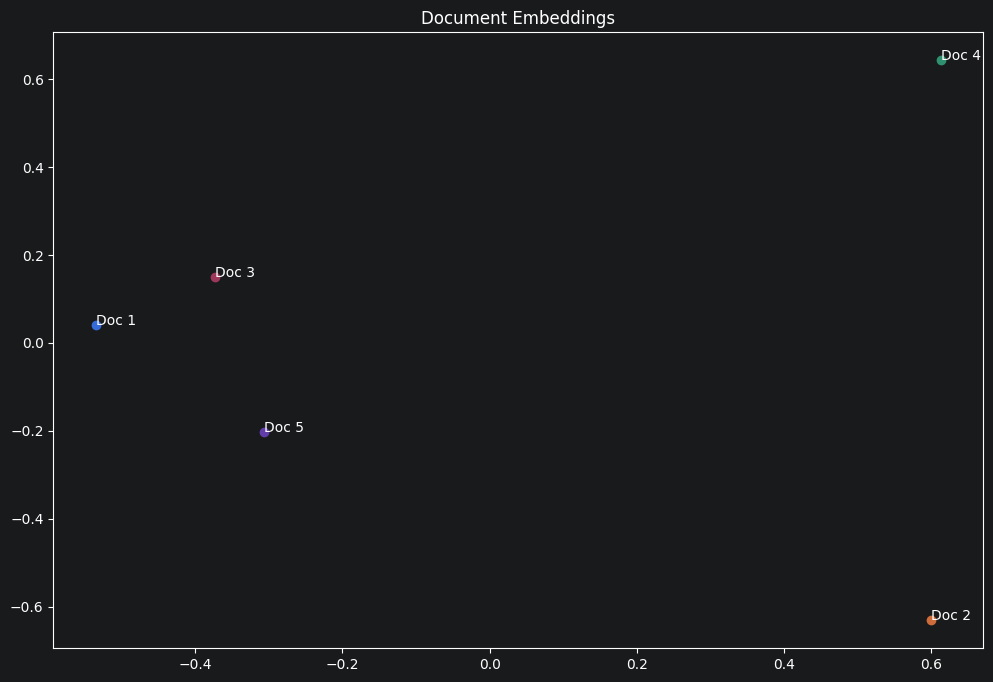

In [17]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data = collection.get(include=["embeddings", "documents"])

vectors = np.array(data["embeddings"])
pca =  PCA(n_components=2)
points = pca.fit_transform(vectors)

plt.figure(figsize=(12,8))

for i, doc in enumerate(data["documents"]):
    plt.scatter(points[i,0], points[i,1])
    plt.annotate(
        f"Doc {i+1}",
        (points[i,0], points[i,1])
    )

plt.title("Document Embeddings")
plt.show()